# Análise de Eficiência Energética em Sistema de Refrigeração Industrial

## Contexto

Sistemas de refrigeração industrial possuem papel estratégico na estabilidade térmica de processos produtivos e representam parcela significativa do consumo energético em plantas industriais.

A eficiência operacional desses sistemas pode ser avaliada por meio do **Coefficient of Performance (COP)**, indicador que relaciona a capacidade de remoção de calor com a potência elétrica consumida.

Este estudo realiza uma análise exploratória do desempenho de um sistema de refrigeração ao longo de uma semana de operação, com foco na identificação de padrões, regimes operacionais e eventos pontuais de degradação de eficiência.


In [2]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np

Note: you may need to restart the kernel to use updated packages.


## Estrutura e Carregamento dos Dados

O conjunto de dados contém variáveis operacionais típicas de um sistema de refrigeração industrial, incluindo temperaturas, vazão, potência elétrica e parâmetros auxiliares.

Nesta etapa, os dados são carregados e inspecionados quanto à sua estrutura, tipos de variáveis e consistência inicial, garantindo base adequada para as etapas subsequentes de cálculo e análise.


In [3]:
data_path = "../data/raw/dados_refrigeracao.csv"
df = pd.read_csv(data_path)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2016 entries, 0 to 2015
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         2016 non-null   object 
 1   temp_entrada_c    2016 non-null   float64
 2   temp_saida_c      2016 non-null   float64
 3   vazao_m3_h        2016 non-null   float64
 4   potencia_kw       2016 non-null   float64
 5   pressao_oleo_bar  2016 non-null   float64
 6   nivel_tanque_pct  2016 non-null   float64
dtypes: float64(6), object(1)
memory usage: 110.4+ KB


## Dicionário de Variáveis

As variáveis utilizadas representam medições típicas de um sistema de refrigeração industrial:

- **temp_entrada_c**  
  Temperatura da água na entrada do sistema (°C).

- **temp_saida_c**  
  Temperatura da água após o processo de resfriamento (°C).

- **vazao_m3_s**  
  Vazão volumétrica de água circulante no sistema (m³/s).

- **potencia_kw**  
  Potência elétrica total consumida pelo sistema (kW).

- **pressao_oleo_bar**  
  Pressão do óleo do compressor (bar).

- **nivel_tanque_pct**  
  Nível do tanque do sistema (%).

Essas variáveis permitem estimar a carga térmica removida e avaliar o desempenho energético por meio do COP.


## Tratamento e Consistência dos Dados

Antes do cálculo dos indicadores de desempenho, foi realizada uma etapa de verificação e preparação dos dados.

Essa etapa inclui:

- Conversão e validação do timestamp
- Tratamento de valores ausentes
- Verificação de inconsistências físicas (ex.: temperaturas invertidas ou potência negativa)
- Preparação das variáveis para cálculo da carga térmica

A qualidade dos dados é etapa essencial em análises industriais, pois medições incorretas podem levar a interpretações equivocadas do desempenho operacional.


### Tratamento do Tempo

A variável `timestamp` representa o instante de cada medição.  
Ela foi convertida para o formato datetime e utilizada como índice temporal, permitindo análises de séries temporais e identificação de padrões ao longo do período analisado.


In [4]:
TS_COL = "timestamp"

# Conversão para datetime
df[TS_COL] = pd.to_datetime(df[TS_COL], errors="coerce")

# Remove registros sem timestamp válido
df = df.dropna(subset=[TS_COL]).copy()

# Ordena cronologicamente
df = df.sort_values(TS_COL).copy()

# Remove timestamps duplicados (mantém o último valor)
df = df.drop_duplicates(subset=[TS_COL], keep="last").copy()

# Define índice temporal para o dataframe
df = df.set_index(TS_COL)

Outros parâmetros

In [5]:
num_cols = [
    "temp_entrada_c",
    "temp_saida_c",
    "vazao_m3_h",
    "potencia_kw",
    "pressao_oleo_bar",
    "nivel_tanque_pct"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Delta T (°C)
df["dT_C"] = df["temp_entrada_c"] - df["temp_saida_c"]

# Flags físicos de invalidez (vazão, potência, temperatura)
df["flag_vazao_invalida"]   = df["vazao_m3_h"] <= 0
df["flag_pot_invalida"]     = df["potencia_kw"] <= 0
df["flag_temp_invertida"]   = df["temp_entrada_c"] <= df["temp_saida_c"]
df["flag_dT_invalido"]      = df["dT_C"] <= 0  # redundante com temp_invertida, mas útil como resumo

# Consolidado de invalidez (pra filtro e auditoria)
df["flag_invalido"] = (
    df["flag_vazao_invalida"]
    | df["flag_pot_invalida"]
    | df["flag_dT_invalido"]
)

# Filtragem dos dados válidos
df_valid = df.loc[~df["flag_invalido"]].copy()

# Vazão em m³/s (assumindo que a tag está em m³/h)
df_valid["Vazao_m3_s"] = df_valid["vazao_m3_h"] / 3600.0

Relatório de arquivos enválidos:

In [6]:
total = len(df)
invalid = df["flag_invalido"].sum()
pct_invalid = invalid / total * 100

resumo_flags = pd.Series({
    "Total de linhas": total,
    "Linhas inválidas": invalid,
    "% inválidas": pct_invalid,
    "Vazão inválida": df["flag_vazao_invalida"].sum(),
    "Potência inválida": df["flag_pot_invalida"].sum(),
    "ΔT inválido": df["flag_dT_invalido"].sum(),
    "Temp invertida": df["flag_temp_invertida"].sum(),
})

resumo_flags


Total de linhas      2016.0
Linhas inválidas        0.0
% inválidas             0.0
Vazão inválida          0.0
Potência inválida       0.0
ΔT inválido             0.0
Temp invertida          0.0
dtype: float64

### Modelagem Física da Carga Térmica

A carga térmica removida pela água foi estimada a partir do balanço de energia:

$\dot{Q} = \dot{m} \cdot c_p \cdot \Delta T$

onde:

- $\dot{m}$ é a vazão mássica (kg/s),
- $c_p$ é o calor específico da água,
- $\Delta T$ é a diferença entre temperatura de entrada e saída.

Para os cálculos, foram considerados:

- Densidade da água: $ \rho = 1000 \, kg/m^3$
- Calor específico: $ c_p = 4180 \, J/(kg \cdot °C)$

A vazão volumétrica foi convertida de $ m^3/s $ para vazão mássica por meio da relação:

$\dot{m} = \rho \cdot \dot{V}$

Essa abordagem permite estimar a potência térmica removida e, consequentemente, calcular o Coefficient of Performance (COP) do sistema.


In [7]:
RHO = 1000.0 # kg/m3
CP = 4180.0 # J/kg.C

# Vazão mássica (kg/s)
df_valid["m_dot_kg_s"] = RHO * df_valid["Vazao_m3_s"]

# Carga térmica removida (W) e (kW)
df_valid["Qdot_W"]  = df_valid["m_dot_kg_s"] * CP * df_valid["dT_C"]
df_valid["Qdot_kW"] = df_valid["Qdot_W"] / 1000.0

# COP (adimensional)
df_valid["COP"] = df_valid["Qdot_kW"] / df_valid["potencia_kw"]

# Filtragem de COPs fisicamente plausíveis (0 < COP <= 20)
df_valid["flag_COP_invalido"] = (df_valid["COP"] <= 0) | (df_valid["COP"] > 20)
df_cop = df_valid.loc[~df_valid["flag_COP_invalido"]].copy()

## Análise Exploratória dos Dados

Nesta etapa foi realizada uma análise exploratória com o objetivo de compreender o comportamento operacional do sistema de refrigeração ao longo do período analisado.

A análise exploratória permite identificar:

- padrões operacionais predominantes,
- variabilidade de desempenho,
- possíveis eventos de degradação de eficiência,
- relações entre o COP e variáveis operacionais relevantes.

As visualizações apresentadas a seguir têm como foco principal o indicador de eficiência energética (COP) e sua interação com parâmetros como vazão, potência elétrica e diferença de temperatura.

Esse tipo de análise constitui uma etapa fundamental na interpretação de dados industriais, pois permite identificar rapidamente comportamentos anômalos ou regimes operacionais distintos antes da aplicação de modelos estatísticos ou preditivos mais avançados.

In [8]:
cop_stats = df_cop["COP"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
cop_stats

count    2016.000000
mean        3.243186
std         0.500108
min         1.486778
10%         2.708801
25%         3.032839
50%         3.326981
75%         3.564948
90%         3.772873
max         4.274710
Name: COP, dtype: float64

A primeira avaliação do desempenho do sistema foi realizada por meio de estatísticas descritivas do COP, incluindo média, mediana e percentis.

Essas métricas permitem observar a distribuição do desempenho energético do sistema e identificar possíveis assimetrias ou presença de valores extremos.


### Evolução Temporal do COP

A análise temporal do COP permite observar a estabilidade operacional do sistema ao longo do período analisado.

Esse tipo de visualização é particularmente útil para identificar:

- variações de eficiência ao longo do tempo,
- eventos operacionais transitórios,
- possíveis regimes distintos de operação.

A linha tracejada representa o valor médio do COP no período analisado, servindo como referência para comparação do desempenho instantâneo do sistema.

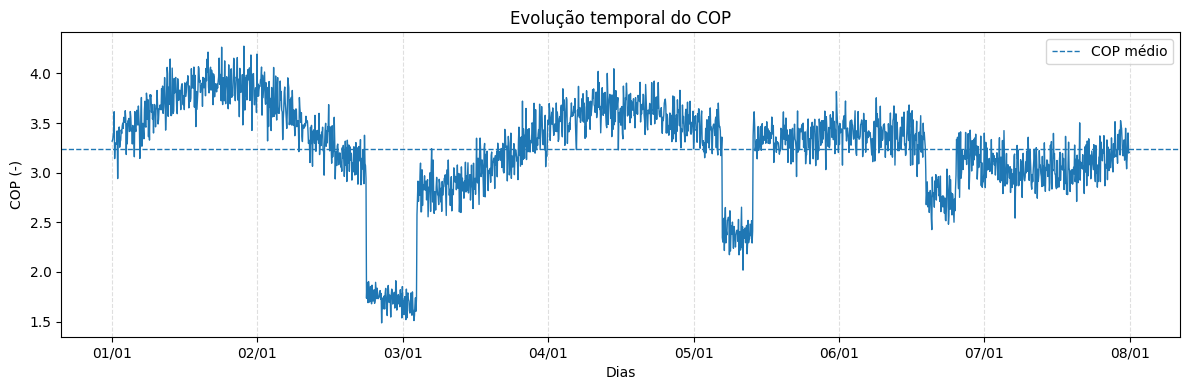

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12,4))

plt.plot(
    df_cop.index,
    df_cop["COP"],
    linewidth=1
)

plt.axhline(
    df_cop["COP"].mean(),
    linestyle="--",
    linewidth=1,
    label="COP médio"
)

plt.title("Evolução temporal do COP")
plt.ylabel("COP (-)")
plt.xlabel("Dias")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()


### Distribuição do COP

Antes de analisar a evolução temporal do desempenho do sistema, é útil observar a distribuição estatística do COP.

O histograma permite identificar o regime operacional predominante, a dispersão dos valores e a presença de eventos de baixa eficiência.

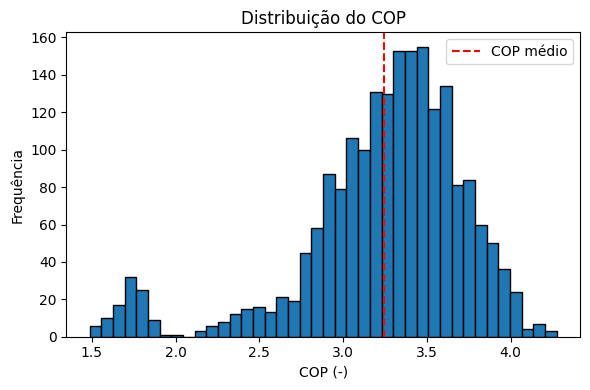

In [23]:
plt.figure(figsize=(6,4))
plt.hist(df_cop["COP"], bins=40, edgecolor='black')
plt.title("Distribuição do COP")
plt.xlabel("COP (-)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.axvline(
    df_cop["COP"].mean(),
    color="red",
    linestyle="--",
    label="COP médio"
)

plt.legend()
plt.show()

A análise estatística do COP indica média de aproximadamente 3,24 e mediana de 3,33, sugerindo um desempenho energético consistente ao longo do período analisado.

Observa-se que cerca de 50% dos valores estão concentrados entre 3,03 e 3,56, caracterizando um regime operacional relativamente estável.

Valores mínimos próximos de 1,5 aparecem de forma esporádica e representam eventos de degradação momentânea de eficiência. Esses pontos correspondem aos períodos de queda abrupta observados anteriormente na análise temporal.

Por outro lado, a presença de valores máximos superiores a 4 indica que o sistema é capaz de operar em condições mais eficientes sob determinadas combinações de carga térmica e consumo elétrico.